# 08 线性回归 + 基础优化算法

## 线性回归

### 线性模型

+ 给定n维的输入 **x**=[x1,x2, ... ,xn]T
+ 线性模型有一个n维权重和一个标准偏差 **w**=[w1,w2, ... ,wn]T , b
+ 输出是输入的加权和： y = w1x1 + w2x2 + ... + wnxn + b
  （向量版本： y = < **w** , **x** > + b）

**线性模型可以看作一个单层的神经网络**
示意图：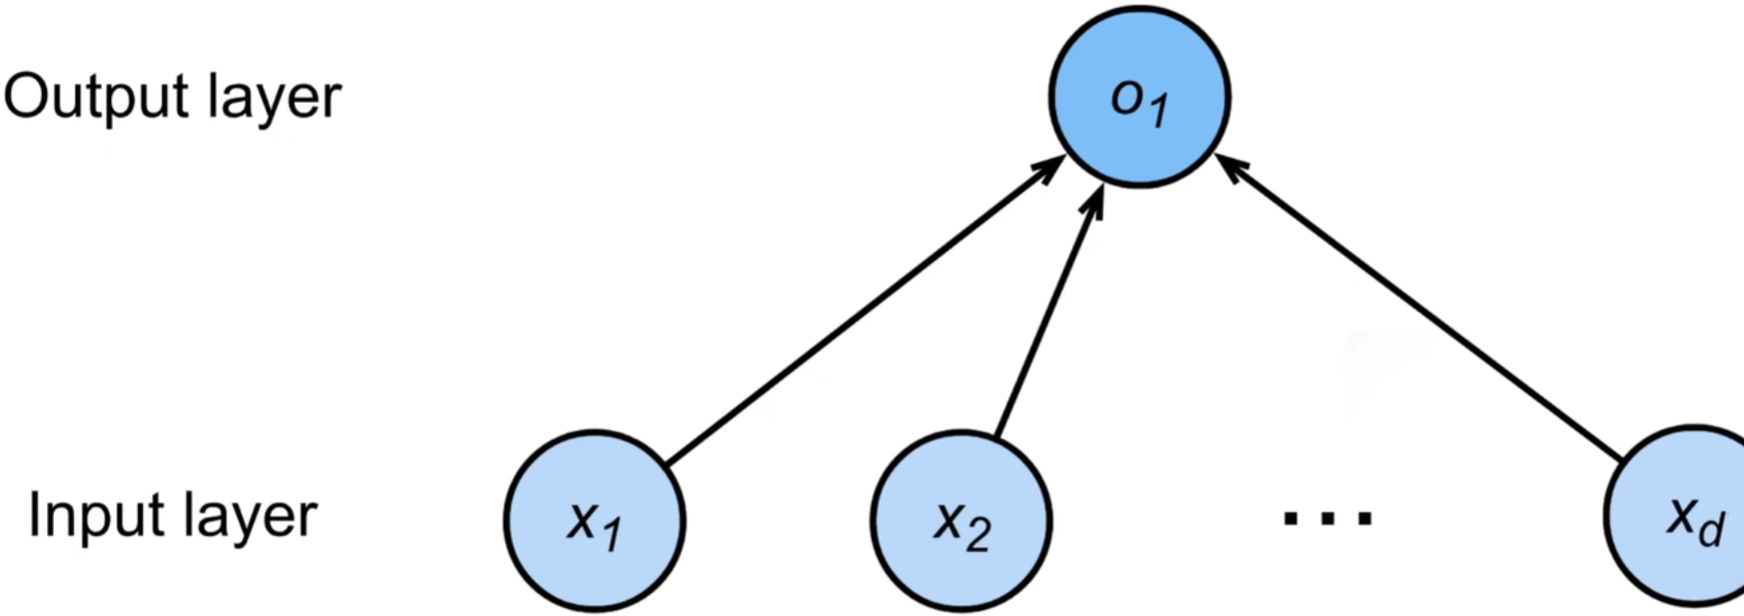
单层：是因为他带权重的层是1

### 衡量预估质量

比较真实值和预估值时，假设y为真实值，y'为预估值，我们可以比较：

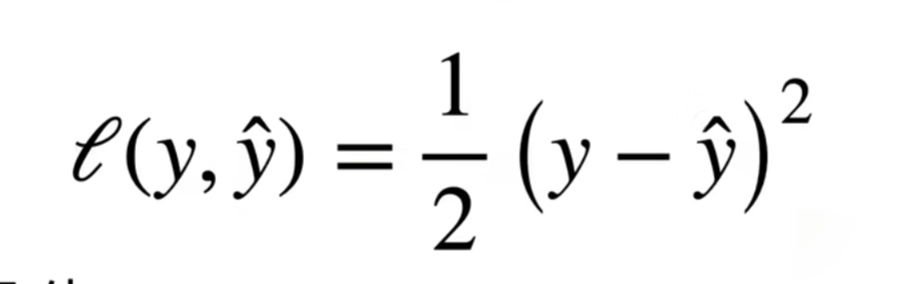

叫做 平方损失

### 训练数据

我们需要收集一些数据点来决定参数值（如 权重和偏差），这被称之为 训练数据 ；
训练数据通常越多越好

假设我们有n个样本，记： **X** =[x1,x2, ... ,xn]T , **y** =[y1,y2, ... ,yn]T

### 参数学习

+ 训练损失：
  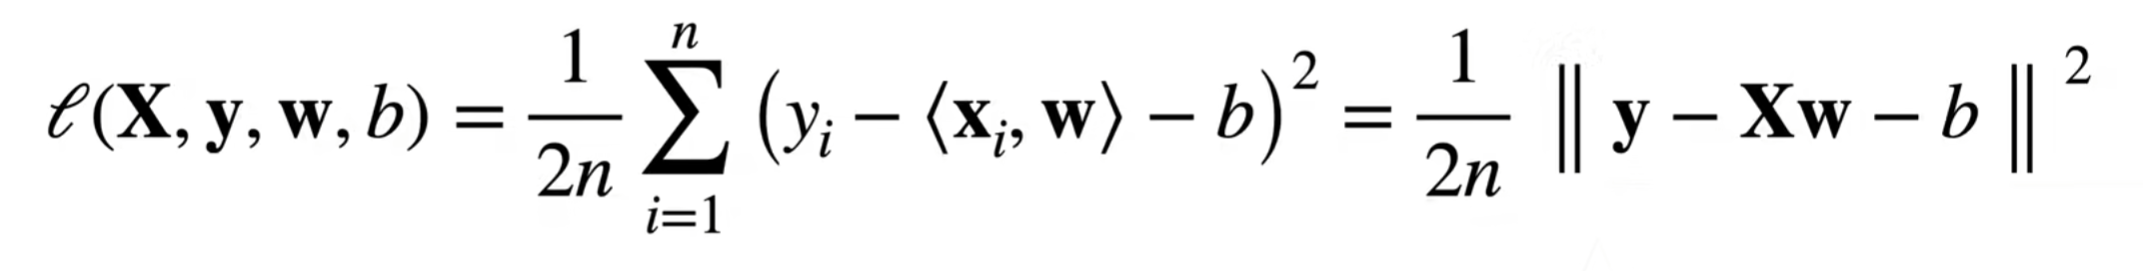
+ 最小化损失来学习参数：选取w和b使其训练损失最小
  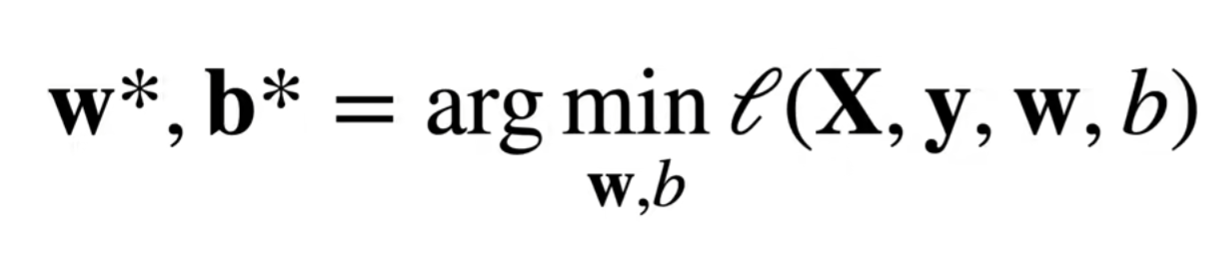

### 线性模型的 显示解

+ 将偏差加入权重
  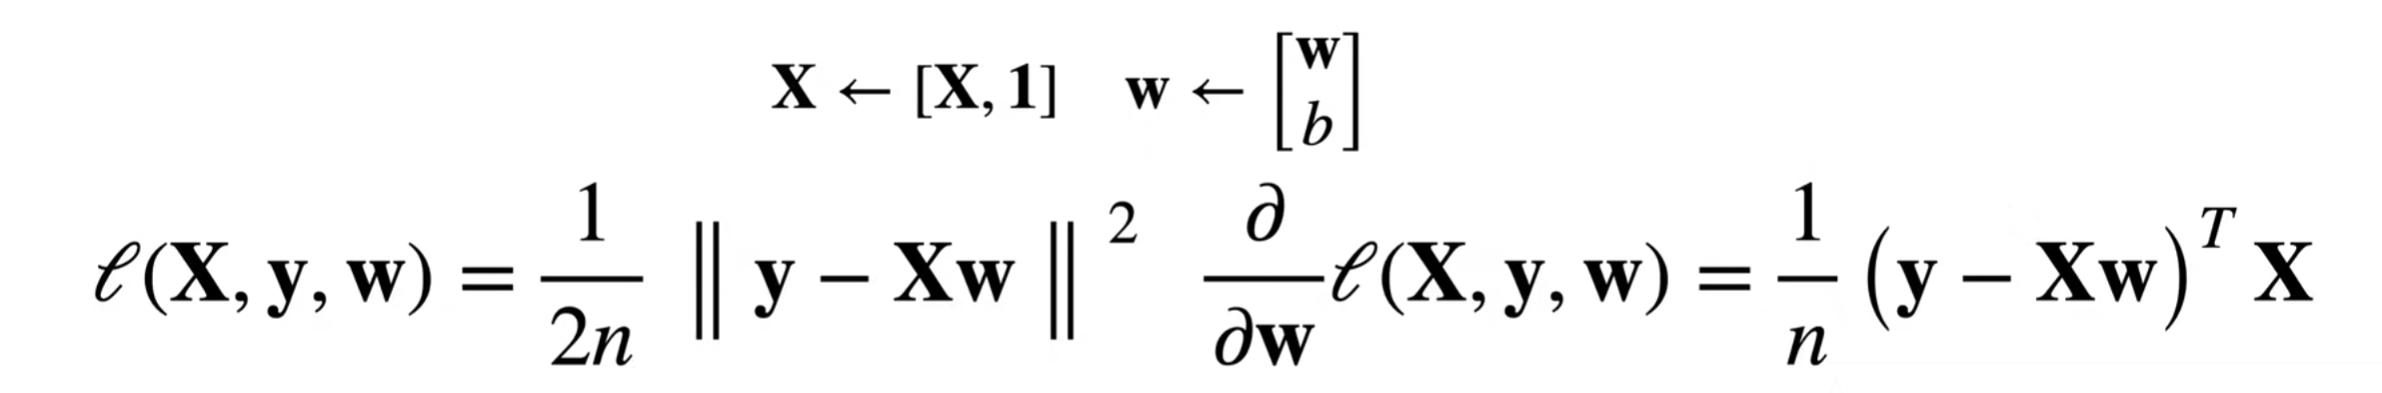
+ 损失是凸函数，所以最优解满足：（唯一的一个有最优解的模型）
  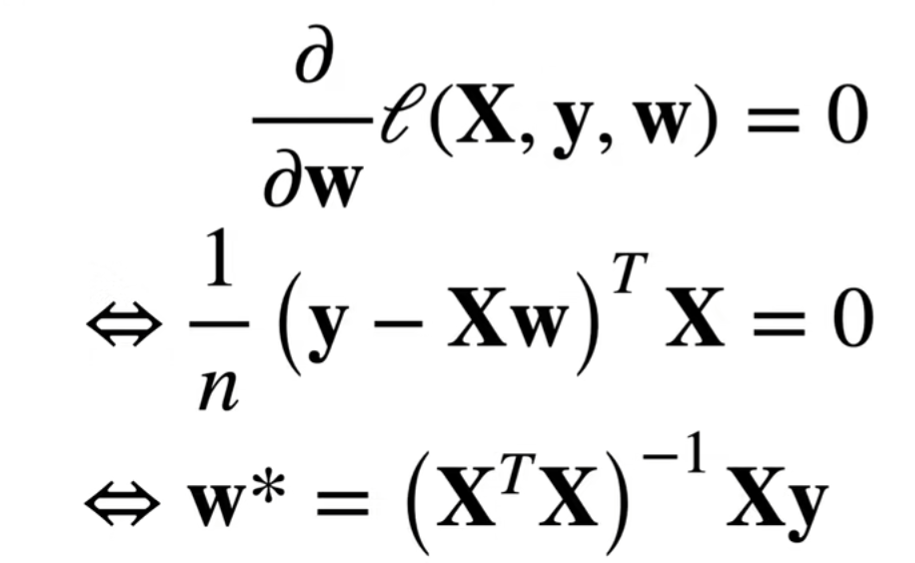

## 基础优化算法

在没有显示解的时候只能使用优化算法来找更优解

### 梯度下降

1. 挑选一个初始值 w0
2. 重复迭代参数 t=1，2，3
   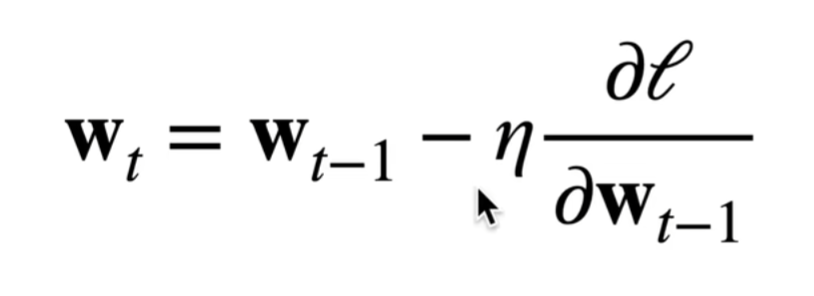
   + 沿梯度方向将增加损失函数值：沿梯度方向是损失函数值增加最快的方向，则负梯度方向就是减少损失函数值的方向
   + 学习率：步长的超参数

示意图：
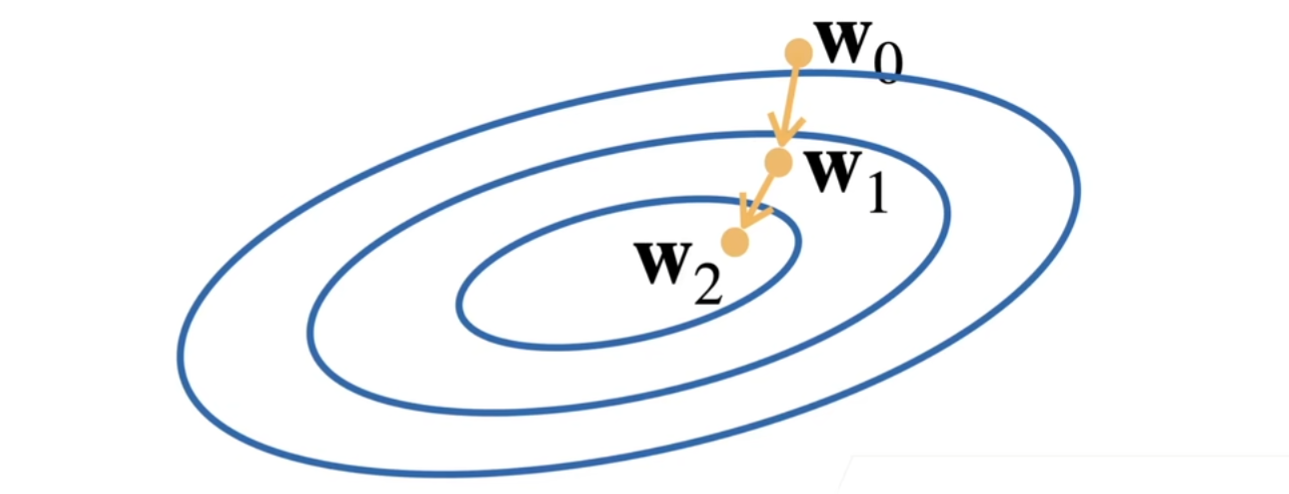

在选择学习率的时候，不能太小（到达一个位置需要走很多步），也不能太大（一步太大的话不好找到所需点而是一直在振荡）

### 小批量随机梯度下降

在整个训练集上算梯度太贵了，一个深度神经网络模型可能需要数分钟到数小时不等

我们可以随机采样b个样本 (i1、i2、 ... 、ib) 来近似损失

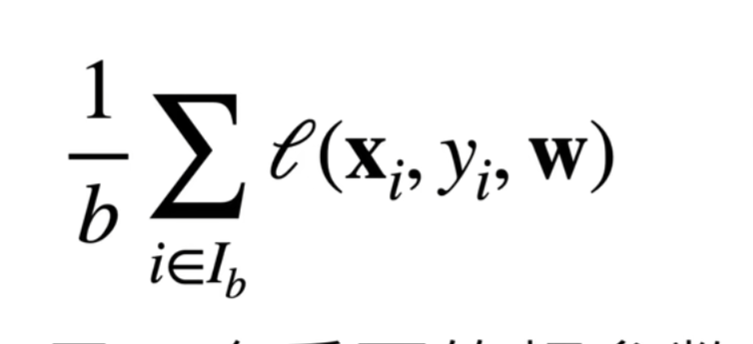

+ b是批量大小，另一个重要的超参数

  + 同样的 批量大小不能太小（每次计算量太小，不适合并行来最大利用计算资源），也不能太大（内存消耗增加，浪费计算）

## 线性回归-从零开始实现

从零开始实现线性回归，包括：数据流水线、模型、损失函数、小批量随机批度下降优化器

In [62]:
%matplotlib inline   
#Jupyter Notebook 里的一行魔法命令，作用是让 matplotlib 画出的图表直接显示在代码单元格的下方，而不是弹出一个独立的新窗口
import random  
#导入内置随机数模块
import torch   
#导入pytorch
from d2l import torch as d2l  
#从 d2l 包中导入基于 PyTorch 框架的实现模块，并将其重命名为 d2l，方便后续直接调用

### 生成数据集

根据带有噪声的线性模型构造一个人造数据集。我们使用线性模型参数w=[2,-3.4]T 、b=4.2和一个噪声项生成数据集及其标签：
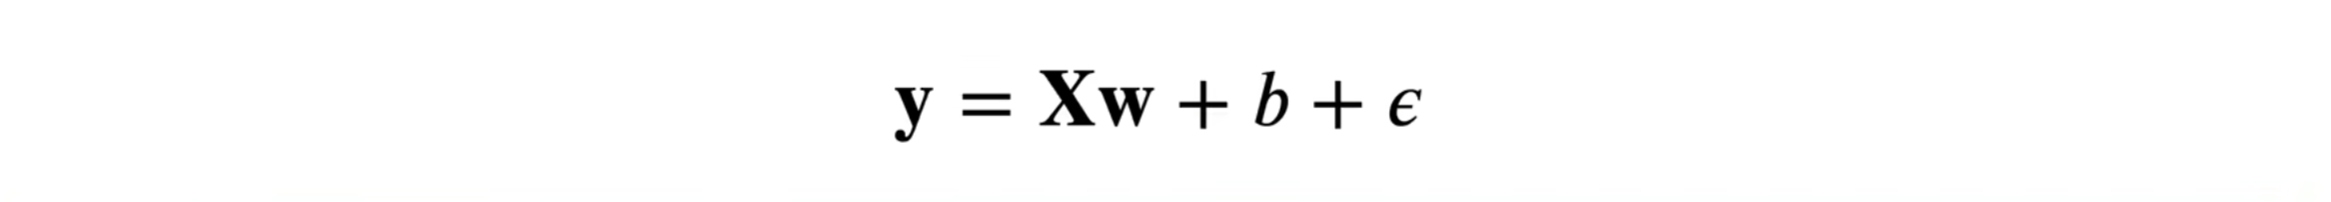

In [63]:
def synthetic_data(w, b, num_examples):
    # 生成y=Xw+b+噪声
    X=torch.normal(0, 1, (num_examples, len(w))) # x是均值为0，方差为1的随机数 大小是 有num_examples个样本 列数是w
    y=torch.matmul(X, w) + b  # y是X与w相乘再加b
    y+=torch.normal(0, 0.01, y.shape)  #再加上一个随机噪声 均值为0，方差为1，形状与y相同
    return X, y.reshape((-1, 1))

true_w=torch.tensor([2, -3.4])
true_b=4.2
features, labels=synthetic_data(true_w, true_b, 1000)  #通过这个函数获得我们的训练样本

features 中的每一行都包含一个二维数据样本， labels 中的每一行都包含一维标签值（一个标量）

In [64]:
print('features:', features[0], '\nlabel:', labels[0]) #看一下两个都是什么东西

features: tensor([-1.2002,  0.4022]) 
label: tensor([0.4327])


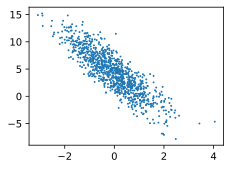

In [65]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1) #把features的第一列detach出来转入numpy中
# 生成第二个特征features[:, 1]和labels的散点图

可以看出来这是线性相关的

### 读取数据集

定义一个 data_iter 函数，该函数接收批量大小、特征矩阵、标签向量作为输入，生成大小为 batch_size 的小批量

In [66]:
def data_iter(batch_size, features, labels):
    num_examples=len(features)
    indices=list(range(num_examples))  # 将indices转为list的形式
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices) # random的函数 将下标随机打乱 这样可以以随机的顺序访问这些样本
    for i in range(0, num_examples, batch_size):  # 每次从0开始到num_examples，步长为batch_size
        batch_indices=torch.tensor(  indices[i: min(i + batch_size, num_examples)]  )  # 这里的min的函数是为了保证不越界
        yield features[batch_indices], labels[batch_indices]

batch_size=10

for X,y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.1125,  0.9157],
        [ 0.7059,  0.1385],
        [ 0.5757,  1.1804],
        [-0.3066, -2.0012],
        [ 1.8574, -0.2642],
        [ 1.4767, -1.1217],
        [ 1.3010, -0.4436],
        [ 1.1113,  1.0827],
        [-1.1192,  0.4535],
        [ 0.1947, -0.1001]]) 
 tensor([[ 1.3025],
        [ 5.1527],
        [ 1.3587],
        [10.3929],
        [ 8.8098],
        [10.9748],
        [ 8.3111],
        [ 2.7493],
        [ 0.4272],
        [ 4.9371]])


这里的 yield 相当于 每次返回一个x和y 不断的调用它就会不断的返回 一直到全部都返回为止

### 初始化模型参数

定义 初始化模型参数

In [67]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

### 定义模型

In [68]:
def linreg(X, w, b):
    # 线性回归模型
    return torch.matmul(X, w)+b

### 定义损失函数

In [69]:
def squared_loss(y_hat, y):
    # 均方损失
    return (y_hat - y.reshape(y_hat.shape))**2 / 2

### 定义优化算法

In [70]:
def sgd(params, lr, batch_size):   # params包含所有参数（list格式），lr是学习率
    #小批量随机梯度下降
    with torch.no_grad():   # 临时禁用梯度计算
        for param in params:
            param -= lr*param.grad / batch_size
            param.grad.zero_()  # param的梯度设定为0

### 训练过程

In [71]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

# 训练的逻辑基本上都是两层for循环
for epoch in range(num_epochs):  # 第一层 就是每一次 对数据扫一遍
    for X, y in data_iter(batch_size, features, labels):  # 第二层 就是每一次拿出一个批量大小的X和y进行学习
        l = loss(net(X, w, b), y)  # X和y的小批量损失  把预测的y和真实的y做损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():  # 在第二层扫完一边后 来评价一下进度（这一段不需要计算梯度）
        train_l = loss(net(features, w, b), labels)   # 把整个数据传入来计算一下loss
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')  # 输出本次内容

epoch 1, loss 0.030530
epoch 2, loss 0.000097
epoch 3, loss 0.000045


这里由于我们使用的是人工数据集，所以可以看到真实的w和b，我们可以比较真实参数和通过训练学到的参数来评估训练的成功程度

In [72]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')  # 真实的w减去我们得到的w
print(f'b的估计误差: {true_b - b}')  # 真实的b减去我们得到的b

w的估计误差: tensor([-0.0006, -0.0005], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0006], grad_fn=<RsubBackward1>)


## 线性回归-简洁实现

通过使用深度学习框架来简洁地实现 线性回归模型

### 生成数据集

直接用框架内已有的函数来生成数据集

In [76]:
import numpy as np
import torch
from torch.utils import data   # 导入 PyTorch 的数据处理工具包（即 torch.utils.data 模块）
from d2l import torch as d2l

true_w=torch.tensor([2, -3.4])
true_b=4.2
features, labels=d2l.synthetic_data(true_w, true_b, 1000)

### 读取数据集

调用框架中现有的API来读取数据

In [79]:
def load_array(data_arrays, batch_size, is_train=True): 
    # 构造一个PyTorch数据迭代器
    dataset=data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size=10
data_iter=load_array((features, labels), batch_size)

next(iter(data_iter))

[tensor([[ 0.0252, -0.6841],
         [-0.9361,  1.3362],
         [-1.1945,  1.3789],
         [ 0.4248, -1.9173],
         [ 0.9327, -2.0068],
         [ 0.2692,  0.7364],
         [-1.5748,  0.6414],
         [-0.0329,  1.5756],
         [-0.5933, -0.2621],
         [-1.7789, -0.4735]]),
 tensor([[ 6.5846],
         [-2.2097],
         [-2.8864],
         [11.5854],
         [12.8811],
         [ 2.2374],
         [-1.1319],
         [-1.2314],
         [ 3.9040],
         [ 2.2419]])]

### 定义模型

使用框架的已经预定义好的层

In [81]:
# nn是神经网络的缩写 包含大量的定义好的层
from torch import nn
# 对于线性回归的模型相当于使用其中的 线性层（或者叫 全连接层）
net = nn.Sequential(nn.Linear(2, 1))
# 它唯一要指定的就是 输入的维度是什么（2）和输出的维度是什么（1）
# nn.Linear是使用的他的线形层，为了后续方便而放在Sequential的容器中

### 初始化模型参数

In [82]:
net[0].weight.data.normal_(0, 0.01)  # weight是访问其w，data是其真实数据，normal_是使用正态分布来替换掉data的值（均值是0，方差是0.01）
net[0].bias.data.fill_(0)  # bias是访问其b，data同上，fill_(0)是将其设置为0

tensor([0.])

### 定义损失函数

计算均方误差 使用的是MSELoss类，也称为 平方范数

In [83]:
loss = nn.MSELoss()

###  定义优化算法

实例化 SGD 实例

In [85]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)
# 在一个optim的模组里面使用SGD，其至少传入两个参数：所有net的参数parameters、学习率lr

### 训练

训练代码则与上部分“从零开始实现”中的相似

In [86]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X) ,y)  # 这里计算预测值y直接用net(X)是因为net中自带有模型参数w和b，则不需要再放进去了
        trainer.zero_grad()  # trainer是优化器，这里先把他的梯度清零
        l.backward()  # 计算其backward 这里是pytorch已经对其做过sum所以不用再做了
        trainer.step()  # 这里是计算出来一次梯度以后，调用step函数进行一次模型的更新
    l = loss(net(features), labels)  # 与前面相同 把所有的features和所有的labels放在一起计算一个loss
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000314
epoch 2, loss 0.000107
epoch 3, loss 0.000107


比较生成数据集的真实参数和通过有限数据训练获得的模型参数

In [87]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

w的估计误差： tensor([-0.0007,  0.0005])
b的估计误差： tensor([-0.0008])
